# MTH-IDS: A Multi-Tiered Hybrid Intrusion Detection System for Internet of Vehicles
This is the code for the paper entitled "[**MTH-IDS: A Multi-Tiered Hybrid Intrusion Detection System for Internet of Vehicles**](https://arxiv.org/pdf/2105.13289.pdf)" accepted in IEEE Internet of Things Journal.  
Authors: Li Yang (liyanghart@gmail.com), Abdallah Moubayed, and Abdallah Shami  
Organization: The Optimized Computing and Communications (OC2) Lab, ECE Department, Western University

If you find this repository useful in your research, please cite:  
L. Yang, A. Moubayed, and A. Shami, “MTH-IDS: A Multi-Tiered Hybrid Intrusion Detection System for Internet of Vehicles,” IEEE Internet of Things Journal, vol. 9, no. 1, pp. 616-632, Jan.1, 2022.

## Import libraries

In [1]:
!wget https://raw.githubusercontent.com/SantiagoEG/FCBF_module/master/FCBF_module.py
!pip install xgboost lightgbm catboost hyperopt imbalanced-learn seaborn

/usr/bin/sh: 1: wget: not found

[notice] A new release of pip is available: 23.3.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,precision_recall_fscore_support
from sklearn.metrics import f1_score,roc_auc_score
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from xgboost import plot_importance

In [4]:
import pandas as pd
import glob
import os

path = './data/' 
all_files = glob.glob(os.path.join(path, "*.csv"))
print(f"Found {len(all_files)} daily files. Starting merge...")

df_list = []
for filename in all_files:
    print(f"Reading: {os.path.basename(filename)}...")
    day_df = pd.read_csv(filename, encoding='cp1252')
    df_list.append(day_df)

complete_df = pd.concat(df_list, axis=0, ignore_index=True)
complete_df.columns = complete_df.columns.str.strip()

mapping = {
    'BENIGN': 0,
    'Bot': 1,
    'FTP-Patator': 2,
    'SSH-Patator': 2,
    'DoS Hulk': 3,
    'DDoS': 3,
    'DoS GoldenEye': 3,
    'DoS slowloris': 3,
    'DoS Slowhttptest': 3,
    'Heartbleed': 3,
    'Infiltration': 4,
    'PortScan': 5,
    'Web Attack ï¿½ Brute Force': 6,
    'Web Attack ï¿½ XSS': 6,
    'Web Attack ï¿½ Sql Injection': 6
}

complete_df['Label'] = complete_df['Label'].map(mapping)

zero_day_df = complete_df[complete_df['Label'] == 4].copy()
known_df = complete_df[complete_df['Label'] != 4].copy()

print(f"\nZERO-DAY SCENARIO CONFIGURED:")
print(f" - Known Traffic for training (df): {known_df.shape[0]} rows")
print(f" - Hidden Infiltration (Zero-Day): {zero_day_df.shape[0]} rows")

df = known_df

os.makedirs('./data MTH', exist_ok=True)
zero_day_df.to_csv('./data MTH/ZeroDay_Infiltration_Samples.csv', index=False)
print("Saved Zero-Day samples to ./data MTH/ZeroDay_Infiltration_Samples.csv")

Found 8 daily files. Starting merge...
Reading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
Reading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
Reading: Friday-WorkingHours-Morning.pcap_ISCX.csv...
Reading: Monday-WorkingHours.pcap_ISCX.csv...
Reading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
Reading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...
Reading: Tuesday-WorkingHours.pcap_ISCX.csv...
Reading: Wednesday-workingHours.pcap_ISCX.csv...

ZERO-DAY SCENARIO CONFIGURED:
 - Known Traffic for training (df): 2830707 rows
 - Hidden Infiltration (Zero-Day): 36 rows
Saved Zero-Day samples to ./data MTH/ZeroDay_Infiltration_Samples.csv


## Read the sampled CICIDS2017 dataset
The CICIDS2017 dataset is publicly available at: https://www.unb.ca/cic/datasets/ids-2017.html  
Due to the large size of this dataset, the sampled subsets of CICIDS2017 is used. The subsets are in the "data" folder.  
If you want to use this code on other datasets (e.g., CAN-intrusion dataset), just change the dataset name and follow the same steps. The models in this code are generic models that can be used in any intrusion detection/network traffic datasets.

In [5]:
#Read dataset
#df = pd.read_csv('./data/CICIDS2017.csv') 
# The results in this code is based on the original CICIDS2017 dataset. Please go to cell [21] if you work on the sampled dataset. 

In [6]:
df

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
1,55054,109,1,1,6,6,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2,55055,52,1,1,6,6,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,46236,34,1,1,6,6,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,54863,3,2,0,12,0,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2830738,53,32215,4,2,112,152,28,28,28.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2830739,53,324,2,2,84,362,42,42,42.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2830740,58030,82,2,1,31,6,31,0,15.5,21.92031,...,32,0.0,0.0,0,0,0.0,0.0,0,0,0
2830741,53,1048635,6,2,192,256,32,32,32.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0


In [7]:
df.Label.value_counts()

Label
0    2273097
3     380699
5     158930
2      13835
6       2180
1       1966
Name: count, dtype: int64

### Preprocessing (normalization and padding values)

In [8]:
# Z-score normalization
features = df.dtypes[df.dtypes != 'object'].index
features = features.drop('Label')
df[features] = df[features].apply(
    lambda x: (x - x.mean()) / (x.std()))
df = df.fillna(0)

### Data sampling
Due to the space limit of GitHub files and the large size of network traffic data, we sample a small-sized subset for model learning using **k-means cluster sampling**

In [9]:
print("Labels already mapped to original integer codes. Skipping re-encoding.")
print(df.Label.value_counts())

Labels already mapped to original integer codes. Skipping re-encoding.
Label
0    2273097
3     380699
5     158930
2      13835
6       2180
1       1966
Name: count, dtype: int64


In [10]:
df.Label.value_counts()

Label
0    2273097
3     380699
5     158930
2      13835
6       2180
1       1966
Name: count, dtype: int64

In [11]:
# retain the minority class instances and sample the majority class instances
df_minor = df[(df['Label'] == 6)]
df_major = df.drop(df_minor.index)

print(f"df_major shape (Will go to K-Means): {df_major.shape}")
print(f"df_minor shape (Protected intact): {df_minor.shape}")

df_major shape (Will go to K-Means): (2828527, 79)
df_minor shape (Protected intact): (2180, 79)


In [12]:
X = df_major.drop(['Label'],axis=1) 
y = df_major.iloc[:, -1].values.reshape(-1,1)
y=np.ravel(y)

In [13]:
# use k-means to cluster the data samples and select a proportion of data from each cluster
from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(n_clusters=1000, random_state=0).fit(X)

In [14]:
klabel=kmeans.labels_
df_major['klabel']=klabel

In [15]:
df_major['klabel'].value_counts()

klabel
289    23028
25     15305
199    12818
856    12679
70     11520
       ...  
705       66
767       63
250       38
742       19
555        3
Name: count, Length: 997, dtype: int64

In [16]:
cols = list(df_major)
cols.insert(78, cols.pop(cols.index('Label')))
df_major = df_major.loc[:, cols]

In [17]:
df_major

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,klabel
0,2.559293,-0.439334,-0.009805,-0.010411,-0.055773,-0.007142,-0.281086,-0.210704,-0.280505,-0.245058,...,-0.125799,-0.104622,-0.149384,-0.101041,-0.351918,-0.109443,-0.356858,-0.338988,0,953
1,2.569630,-0.439331,-0.011139,-0.009408,-0.056402,-0.007139,-0.281086,-0.210704,-0.280505,-0.245058,...,-0.125799,-0.104622,-0.149384,-0.101041,-0.351918,-0.109443,-0.356858,-0.338988,0,557
2,2.569685,-0.439332,-0.011139,-0.009408,-0.056402,-0.007139,-0.281086,-0.210704,-0.280505,-0.245058,...,-0.125799,-0.104622,-0.149384,-0.101041,-0.351918,-0.109443,-0.356858,-0.338988,0,484
3,2.087343,-0.439333,-0.011139,-0.009408,-0.056402,-0.007139,-0.281086,-0.210704,-0.280505,-0.245058,...,-0.125799,-0.104622,-0.149384,-0.101041,-0.351918,-0.109443,-0.356858,-0.338988,0,808
4,2.559184,-0.439334,-0.009805,-0.010411,-0.055773,-0.007142,-0.281086,-0.210704,-0.280505,-0.245058,...,-0.125799,-0.104622,-0.149384,-0.101041,-0.351918,-0.109443,-0.356858,-0.338988,0,953
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2830738,-0.438564,-0.438377,-0.007138,-0.008405,-0.045300,-0.007075,-0.250410,0.153898,-0.162282,-0.245058,...,-0.125799,-0.104622,-0.149384,-0.101041,-0.351918,-0.109443,-0.356858,-0.338988,0,970
2830739,-0.438564,-0.439324,-0.009805,-0.008405,-0.048232,-0.006982,-0.230890,0.385918,-0.087049,-0.245058,...,-0.125799,-0.104622,-0.149384,-0.101041,-0.351918,-0.109443,-0.356858,-0.338988,0,423
2830740,2.732398,-0.439331,-0.009805,-0.009408,-0.053783,-0.007139,-0.246227,-0.310141,-0.229454,-0.167102,...,-0.125799,-0.104622,-0.149384,-0.101041,-0.351918,-0.109443,-0.356858,-0.338988,0,7
2830741,-0.438564,-0.408174,-0.004470,-0.008405,-0.036921,-0.007029,-0.244833,0.220189,-0.140787,-0.245058,...,-0.125799,-0.104622,-0.149384,-0.101041,-0.351918,-0.109443,-0.356858,-0.338988,0,657


In [18]:
def typicalSampling(group):
    name = group.name
    frac = 0.008
    return group.sample(frac=frac)

result = df_major.groupby(
    'klabel', group_keys=False
).apply(typicalSampling)

In [19]:
result['Label'].value_counts()

Label
0    18173
3     3073
5     1261
2      106
1       14
Name: count, dtype: int64

In [20]:
result

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
1732710,-0.438564,-0.439317,-0.011139,-0.009408,-0.051479,-0.007092,-0.215552,0.568219,-0.027938,-0.245058,...,0.002545,-0.125799,-0.104622,-0.149384,-0.101041,-0.351918,-0.109443,-0.356858,-0.338988,0
1775574,-0.438564,-0.438419,-0.011139,-0.009408,-0.051584,-0.007092,-0.216946,0.551646,-0.033311,-0.245058,...,0.002556,-0.125799,-0.104622,-0.149384,-0.101041,-0.351918,-0.109443,-0.356858,-0.338988,0
1464290,-0.438564,-0.438418,-0.011139,-0.009408,-0.051584,-0.007092,-0.216946,0.551646,-0.033311,-0.245058,...,0.002556,-0.125799,-0.104622,-0.149384,-0.101041,-0.351918,-0.109443,-0.356858,-0.338988,0
2635723,-0.438564,-0.439321,-0.011139,-0.009408,-0.051479,-0.007094,-0.215552,0.568219,-0.027938,-0.245058,...,0.002556,-0.125799,-0.104622,-0.149384,-0.101041,-0.351918,-0.109443,-0.356858,-0.338988,0
605260,-0.438564,-0.437909,-0.011139,-0.009408,-0.051584,-0.007092,-0.216946,0.551646,-0.033311,-0.245058,...,0.002545,-0.125799,-0.104622,-0.149384,-0.101041,-0.351918,-0.109443,-0.356858,-0.338988,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1278969,-0.436649,-0.439320,-0.009805,-0.008405,-0.020582,-0.006984,-0.046836,2.573532,0.622288,-0.245058,...,0.002545,-0.125799,-0.104622,-0.149384,-0.101041,-0.351918,-0.109443,-0.356858,-0.338988,0
2755116,-0.436649,-0.439320,-0.009805,-0.008405,-0.019744,-0.006984,-0.041258,2.639823,0.643783,-0.245058,...,0.002556,-0.125799,-0.104622,-0.149384,-0.101041,-0.351918,-0.109443,-0.356858,-0.338988,0
1476550,-0.420187,-0.439330,-0.009805,-0.008405,-0.022886,-0.006998,-0.062174,2.391231,0.563176,-0.245058,...,0.002556,-0.125799,-0.104622,-0.149384,-0.101041,-0.351918,-0.109443,-0.356858,-0.338988,0
103115,-0.420187,-0.439326,-0.009805,-0.008405,-0.013670,-0.006998,-0.000822,3.120436,0.799622,-0.245058,...,0.002545,-0.125799,-0.104622,-0.149384,-0.101041,-0.351918,-0.109443,-0.356858,-0.338988,0


In [21]:
import os
result = result.drop(['klabel'], axis=1, errors='ignore')
result = pd.concat([result, df_minor], axis=0, ignore_index=True)

In [22]:
os.makedirs('./data MTH', exist_ok=True)
result.to_csv('./data MTH/CICIDS2017_sample_km.csv', index=0)
print("Saved sampled dataset to ./data MTH/CICIDS2017_sample_km.csv")

Saved sampled dataset to ./data MTH/CICIDS2017_sample_km.csv


### split train set and test set

In [23]:
# Read the sampled dataset
df=pd.read_csv('./data MTH/CICIDS2017_sample_km.csv')

In [24]:
X = df.drop(['Label'],axis=1).values
y = df.iloc[:, -1].values.reshape(-1,1)
y=np.ravel(y)

le_y = LabelEncoder()
y = le_y.fit_transform(y)

print("Sequential labels prepared for XGBoost:", np.unique(y))

Sequential labels prepared for XGBoost: [0 1 2 3 4 5]


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size = 0.8, test_size = 0.2, random_state = 0,stratify = y)

## Feature engineering

### Feature selection by information gain

In [26]:
from sklearn.feature_selection import mutual_info_classif
importances = mutual_info_classif(X_train, y_train)

In [27]:
# calculate the sum of importance scores
features = df.drop(['Label'], axis=1).columns

f_list = sorted(zip(map(lambda x: round(x, 4), importances), features), reverse=True)
Sum = 0
fs = []
for i in range(0, len(f_list)):
    Sum = Sum + f_list[i][0]
    fs.append(f_list[i][1])

In [28]:
# select the important features from top to bottom until the accumulated importance reaches 90%
f_list2 = sorted(zip(map(lambda x: round(x, 4), importances/Sum), features), reverse=True)
Sum2 = 0
fs = []
for i in range(0, len(f_list2)):
    Sum2 = Sum2 + f_list2[i][0]
    fs.append(f_list2[i][1])
    if Sum2>=0.9:
        break        

In [29]:
X_fs = df[fs].values

In [30]:
X_fs.shape

(24807, 46)

### Feature selection by Fast Correlation Based Filter (FCBF)

The module is imported from the GitHub repo: https://github.com/SantiagoEG/FCBF_module

In [31]:
import urllib.request
import os

url = "https://raw.githubusercontent.com/SantiagoEG/FCBF_module/master/FCBF_module.py"

print("Descargando FCBF_module.py de forma segura...")
try:
    urllib.request.urlretrieve(url, "FCBF_module.py")
    if os.path.exists("FCBF_module.py"):
        print("Archivo FCBF_module.py descargado con exito en tu directorio actual")
    else:
        print("El archivo no se pudo guardar.")
except Exception as e:
    print(f"Error en la descarga: {e}")

Descargando FCBF_module.py de forma segura...
Archivo FCBF_module.py descargado con exito en tu directorio actual


In [32]:
from FCBF_module import FCBF, FCBFK, FCBFiP, get_i
fcbf = FCBFK(k = 20)
#fcbf.fit(X_fs, y)

In [33]:
X_fss = fcbf.fit_transform(X_fs,y)

In [34]:
X_fss.shape

(24807, 20)

### Re-split train & test sets after feature selection

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X_fss,y, train_size = 0.8, test_size = 0.2, random_state = 0,stratify = y)

In [36]:
X_train.shape

(19845, 20)

In [37]:
pd.Series(y_train).value_counts()

0    14538
3     2458
5     1744
4     1009
2       85
1       11
Name: count, dtype: int64

### SMOTE to solve class-imbalance

In [38]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy={2: 1000})

In [39]:
X_train, y_train = smote.fit_resample(X_train, y_train)

In [40]:
pd.Series(y_train).value_counts()

0    14538
3     2458
5     1744
4     1009
2     1000
1       11
Name: count, dtype: int64

## Machine learning model training

### Training four base learners: decision tree, random forest, extra trees, XGBoost

#### Apply XGBoost

Accuracy of XGBoost: 0.9935509875050383
Precision of XGBoost: 0.9936170517543811
Recall of XGBoost: 0.9935509875050383
F1-score of XGBoost: 0.99354608922096
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      3635
           1       1.00      0.67      0.80         3
           2       0.91      1.00      0.95        21
           3       0.98      0.99      0.99       615
           4       0.99      0.98      0.98       252
           5       0.98      1.00      0.99       436

    accuracy                           0.99      4962
   macro avg       0.98      0.94      0.95      4962
weighted avg       0.99      0.99      0.99      4962



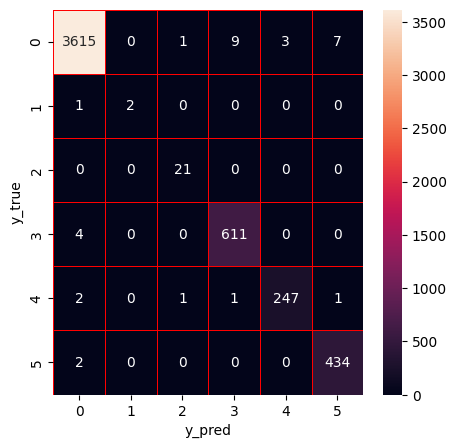

In [41]:
xg = xgb.XGBClassifier(n_estimators = 10)
xg.fit(X_train,y_train)
xg_score=xg.score(X_test,y_test)
y_predict=xg.predict(X_test)
y_true=y_test
print('Accuracy of XGBoost: '+ str(xg_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of XGBoost: '+(str(precision)))
print('Recall of XGBoost: '+(str(recall)))
print('F1-score of XGBoost: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

#### Hyperparameter optimization (HPO) of XGBoost using Bayesian optimization with tree-based Parzen estimator (BO-TPE)
Based on the GitHub repo for HPO: https://github.com/LiYangHart/Hyperparameter-Optimization-of-Machine-Learning-Algorithms

In [42]:
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials
from sklearn.model_selection import cross_val_score, StratifiedKFold
def objective(params):
    params = {
        'n_estimators': int(params['n_estimators']), 
        'max_depth': int(params['max_depth']),
        'learning_rate':  abs(float(params['learning_rate'])),

    }
    clf = xgb.XGBClassifier( **params)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    score = accuracy_score(y_test, y_pred)

    return {'loss':-score, 'status': STATUS_OK }

space = {
    'n_estimators': hp.quniform('n_estimators', 10, 100, 5),
    'max_depth': hp.quniform('max_depth', 4, 100, 1),
    'learning_rate': hp.normal('learning_rate', 0.01, 0.9),
}

best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=20)
print("XGBoost: Hyperopt estimated optimum {}".format(best))

100%|████████████████████████████████████████████████| 20/20 [00:06<00:00,  3.07trial/s, best loss: -0.9965739621120516]
XGBoost: Hyperopt estimated optimum {'learning_rate': 0.5197884688068892, 'max_depth': 91.0, 'n_estimators': 45.0}


Accuracy of XGBoost: 0.9963724304715841
Precision of XGBoost: 0.9963928618867108
Recall of XGBoost: 0.9963724304715841
F1-score of XGBoost: 0.9963572216578173
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3635
           1       1.00      0.67      0.80         3
           2       0.95      1.00      0.98        21
           3       1.00      0.99      0.99       615
           4       0.99      1.00      0.99       252
           5       0.99      1.00      0.99       436

    accuracy                           1.00      4962
   macro avg       0.99      0.94      0.96      4962
weighted avg       1.00      1.00      1.00      4962



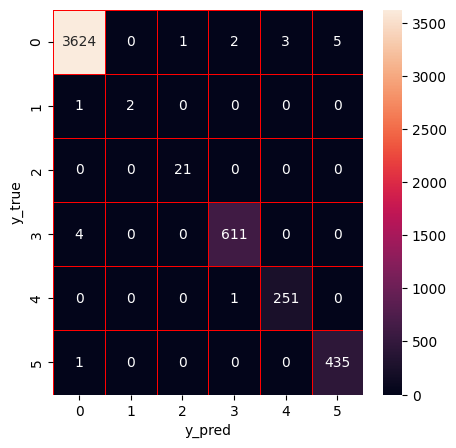

In [43]:
xg = xgb.XGBClassifier(learning_rate= 0.7340229699980686, n_estimators = 70, max_depth = 14)
xg.fit(X_train,y_train)
xg_score=xg.score(X_test,y_test)
y_predict=xg.predict(X_test)
y_true=y_test
print('Accuracy of XGBoost: '+ str(xg_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of XGBoost: '+(str(precision)))
print('Recall of XGBoost: '+(str(recall)))
print('F1-score of XGBoost: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [44]:
xg_train=xg.predict(X_train)
xg_test=xg.predict(X_test)

#### Apply RF

Accuracy of RF: 0.9955663039097138
Precision of RF: 0.9955739717981996
Recall of RF: 0.9955663039097138
F1-score of RF: 0.9955486381468918
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3635
           1       1.00      0.67      0.80         3
           2       1.00      1.00      1.00        21
           3       1.00      0.99      0.99       615
           4       0.99      0.99      0.99       252
           5       0.98      0.99      0.99       436

    accuracy                           1.00      4962
   macro avg       0.99      0.94      0.96      4962
weighted avg       1.00      1.00      1.00      4962



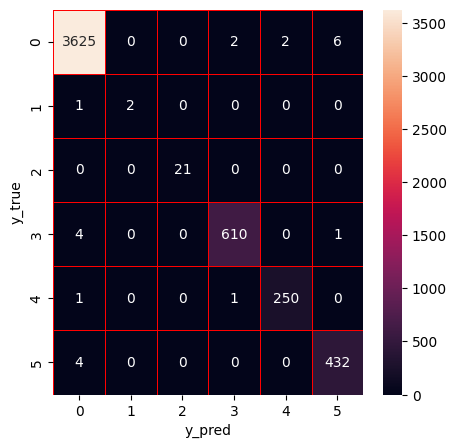

In [45]:
rf = RandomForestClassifier(random_state = 0)
rf.fit(X_train,y_train) 
rf_score=rf.score(X_test,y_test)
y_predict=rf.predict(X_test)
y_true=y_test
print('Accuracy of RF: '+ str(rf_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of RF: '+(str(precision)))
print('Recall of RF: '+(str(recall)))
print('F1-score of RF: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

#### Hyperparameter optimization (HPO) of random forest using Bayesian optimization with tree-based Parzen estimator (BO-TPE)
Based on the GitHub repo for HPO: https://github.com/LiYangHart/Hyperparameter-Optimization-of-Machine-Learning-Algorithms

In [46]:
# Hyperparameter optimization of random forest
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials
from sklearn.model_selection import cross_val_score, StratifiedKFold
# Define the objective function
def objective(params):
    params = {
        'n_estimators': int(params['n_estimators']), 
        'max_depth': int(params['max_depth']),
        'max_features': int(params['max_features']),
        "min_samples_split":int(params['min_samples_split']),
        "min_samples_leaf":int(params['min_samples_leaf']),
        "criterion":str(params['criterion'])
    }
    clf = RandomForestClassifier( **params)
    clf.fit(X_train,y_train)
    score=clf.score(X_test,y_test)

    return {'loss':-score, 'status': STATUS_OK }
# Define the hyperparameter configuration space
space = {
    'n_estimators': hp.quniform('n_estimators', 10, 200, 1),
    'max_depth': hp.quniform('max_depth', 5, 50, 1),
    "max_features":hp.quniform('max_features', 1, 20, 1),
    "min_samples_split":hp.quniform('min_samples_split',2,11,1),
    "min_samples_leaf":hp.quniform('min_samples_leaf',1,11,1),
    "criterion":hp.choice('criterion',['gini','entropy'])
}

best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=20)
print("Random Forest: Hyperopt estimated optimum {}".format(best))

100%|████████████████████████████████████████████████| 20/20 [00:59<00:00,  2.98s/trial, best loss: -0.9945586457073761]
Random Forest: Hyperopt estimated optimum {'criterion': 0, 'max_depth': 27.0, 'max_features': 5.0, 'min_samples_leaf': 2.0, 'min_samples_split': 5.0, 'n_estimators': 59.0}


Accuracy of RF: 0.9947601773478436
Precision of RF: 0.9948038679841983
Recall of RF: 0.9947601773478436
F1-score of RF: 0.9947483136293048
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3635
           1       1.00      0.67      0.80         3
           2       0.95      1.00      0.98        21
           3       0.99      0.99      0.99       615
           4       0.99      0.98      0.99       252
           5       0.98      1.00      0.99       436

    accuracy                           0.99      4962
   macro avg       0.99      0.94      0.96      4962
weighted avg       0.99      0.99      0.99      4962



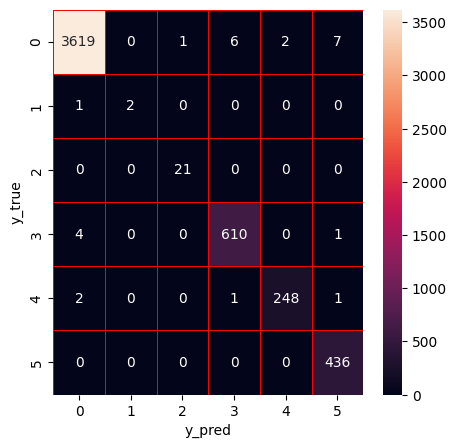

In [47]:
rf_hpo = RandomForestClassifier(n_estimators = 71, min_samples_leaf = 1, max_depth = 46, min_samples_split = 9, max_features = 20, criterion = 'entropy')
rf_hpo.fit(X_train,y_train)
rf_score=rf_hpo.score(X_test,y_test)
y_predict=rf_hpo.predict(X_test)
y_true=y_test
print('Accuracy of RF: '+ str(rf_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of RF: '+(str(precision)))
print('Recall of RF: '+(str(recall)))
print('F1-score of RF: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [48]:
rf_train=rf_hpo.predict(X_train)
rf_test=rf_hpo.predict(X_test)

#### Apply DT

Accuracy of DT: 0.994155582426441
Precision of DT: 0.9942653102892266
Recall of DT: 0.994155582426441
F1-score of DT: 0.9942017757076617
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3635
           1       0.50      0.67      0.57         3
           2       1.00      1.00      1.00        21
           3       0.99      0.99      0.99       615
           4       0.98      0.99      0.99       252
           5       0.99      0.99      0.99       436

    accuracy                           0.99      4962
   macro avg       0.91      0.94      0.92      4962
weighted avg       0.99      0.99      0.99      4962



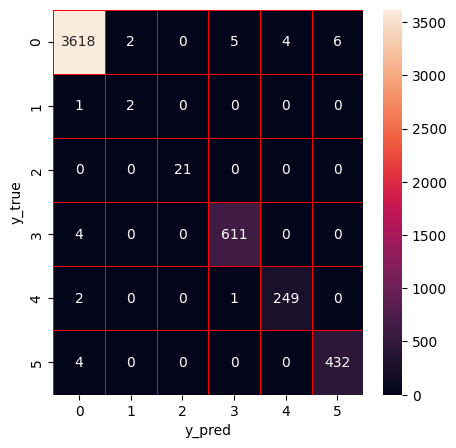

In [49]:
dt = DecisionTreeClassifier(random_state = 0)
dt.fit(X_train,y_train) 
dt_score=dt.score(X_test,y_test)
y_predict=dt.predict(X_test)
y_true=y_test
print('Accuracy of DT: '+ str(dt_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of DT: '+(str(precision)))
print('Recall of DT: '+(str(recall)))
print('F1-score of DT: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

#### Hyperparameter optimization (HPO) of decision tree using Bayesian optimization with tree-based Parzen estimator (BO-TPE)
Based on the GitHub repo for HPO: https://github.com/LiYangHart/Hyperparameter-Optimization-of-Machine-Learning-Algorithms

In [50]:
# Hyperparameter optimization of decision tree
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials
from sklearn.model_selection import cross_val_score, StratifiedKFold
# Define the objective function
def objective(params):
    params = {
        'max_depth': int(params['max_depth']),
        'max_features': int(params['max_features']),
        "min_samples_split":int(params['min_samples_split']),
        "min_samples_leaf":int(params['min_samples_leaf']),
        "criterion":str(params['criterion'])
    }
    clf = DecisionTreeClassifier( **params)
    clf.fit(X_train,y_train)
    score=clf.score(X_test,y_test)

    return {'loss':-score, 'status': STATUS_OK }
# Define the hyperparameter configuration space
space = {
    'max_depth': hp.quniform('max_depth', 5, 50, 1),
    "max_features":hp.quniform('max_features', 1, 20, 1),
    "min_samples_split":hp.quniform('min_samples_split',2,11,1),
    "min_samples_leaf":hp.quniform('min_samples_leaf',1,11,1),
    "criterion":hp.choice('criterion',['gini','entropy'])
}

best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=50)
print("Decision tree: Hyperopt estimated optimum {}".format(best))

100%|████████████████████████████████████████████████| 50/50 [00:03<00:00, 14.89trial/s, best loss: -0.9939540507859734]
Decision tree: Hyperopt estimated optimum {'criterion': 0, 'max_depth': 32.0, 'max_features': 12.0, 'min_samples_leaf': 4.0, 'min_samples_split': 2.0}


Accuracy of DT: 0.9919387343812979
Precision of DT: 0.9919578158289222
Recall of DT: 0.9919387343812979
F1-score of DT: 0.9919121405694745
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3635
           1       1.00      0.67      0.80         3
           2       0.91      1.00      0.95        21
           3       0.99      0.99      0.99       615
           4       0.98      0.96      0.97       252
           5       0.99      0.98      0.98       436

    accuracy                           0.99      4962
   macro avg       0.98      0.93      0.95      4962
weighted avg       0.99      0.99      0.99      4962



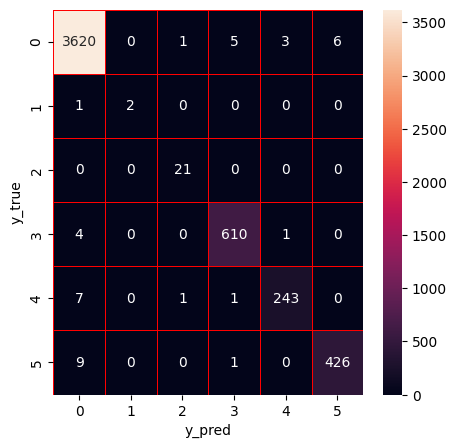

In [51]:
dt_hpo = DecisionTreeClassifier(min_samples_leaf = 2, max_depth = 47, min_samples_split = 3, max_features = 19, criterion = 'gini')
dt_hpo.fit(X_train,y_train)
dt_score=dt_hpo.score(X_test,y_test)
y_predict=dt_hpo.predict(X_test)
y_true=y_test
print('Accuracy of DT: '+ str(dt_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of DT: '+(str(precision)))
print('Recall of DT: '+(str(recall)))
print('F1-score of DT: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [52]:
dt_train=dt_hpo.predict(X_train)
dt_test=dt_hpo.predict(X_test)

#### Apply ET

Accuracy of ET: 0.9951632406287787
Precision of ET: 0.9951848843424125
Recall of ET: 0.9951632406287787
F1-score of ET: 0.9951466179322236
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3635
           1       1.00      0.67      0.80         3
           2       0.95      1.00      0.98        21
           3       0.99      0.99      0.99       615
           4       0.99      0.99      0.99       252
           5       0.98      1.00      0.99       436

    accuracy                           1.00      4962
   macro avg       0.99      0.94      0.96      4962
weighted avg       1.00      1.00      1.00      4962



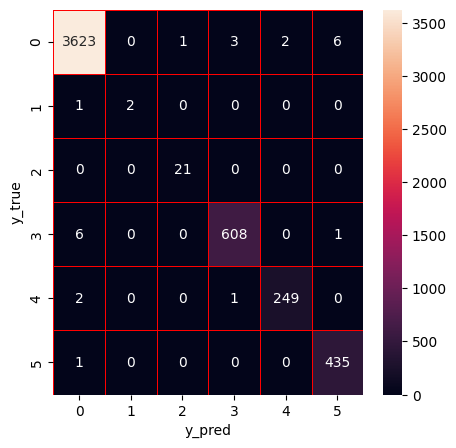

In [53]:
et = ExtraTreesClassifier(random_state = 0)
et.fit(X_train,y_train) 
et_score=et.score(X_test,y_test)
y_predict=et.predict(X_test)
y_true=y_test
print('Accuracy of ET: '+ str(et_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of ET: '+(str(precision)))
print('Recall of ET: '+(str(recall)))
print('F1-score of ET: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

#### Hyperparameter optimization (HPO) of extra trees using Bayesian optimization with tree-based Parzen estimator (BO-TPE)
Based on the GitHub repo for HPO: https://github.com/LiYangHart/Hyperparameter-Optimization-of-Machine-Learning-Algorithms

In [54]:
# Hyperparameter optimization of extra trees
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials
from sklearn.model_selection import cross_val_score, StratifiedKFold
# Define the objective function
def objective(params):
    params = {
        'n_estimators': int(params['n_estimators']), 
        'max_depth': int(params['max_depth']),
        'max_features': int(params['max_features']),
        "min_samples_split":int(params['min_samples_split']),
        "min_samples_leaf":int(params['min_samples_leaf']),
        "criterion":str(params['criterion'])
    }
    clf = ExtraTreesClassifier( **params)
    clf.fit(X_train,y_train)
    score=clf.score(X_test,y_test)

    return {'loss':-score, 'status': STATUS_OK }
# Define the hyperparameter configuration space
space = {
    'n_estimators': hp.quniform('n_estimators', 10, 200, 1),
    'max_depth': hp.quniform('max_depth', 5, 50, 1),
    "max_features":hp.quniform('max_features', 1, 20, 1),
    "min_samples_split":hp.quniform('min_samples_split',2,11,1),
    "min_samples_leaf":hp.quniform('min_samples_leaf',1,11,1),
    "criterion":hp.choice('criterion',['gini','entropy'])
}

best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=20)
print("Random Forest: Hyperopt estimated optimum {}".format(best))

100%|████████████████████████████████████████████████| 20/20 [00:24<00:00,  1.21s/trial, best loss: -0.9945586457073761]
Random Forest: Hyperopt estimated optimum {'criterion': 1, 'max_depth': 45.0, 'max_features': 3.0, 'min_samples_leaf': 1.0, 'min_samples_split': 6.0, 'n_estimators': 187.0}


Accuracy of ET: 0.9959693671906489
Precision of ET: 0.9959889330710605
Recall of ET: 0.9959693671906489
F1-score of ET: 0.9959534755744689
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3635
           1       1.00      0.67      0.80         3
           2       0.95      1.00      0.98        21
           3       1.00      0.99      0.99       615
           4       0.99      0.99      0.99       252
           5       0.99      1.00      0.99       436

    accuracy                           1.00      4962
   macro avg       0.99      0.94      0.96      4962
weighted avg       1.00      1.00      1.00      4962



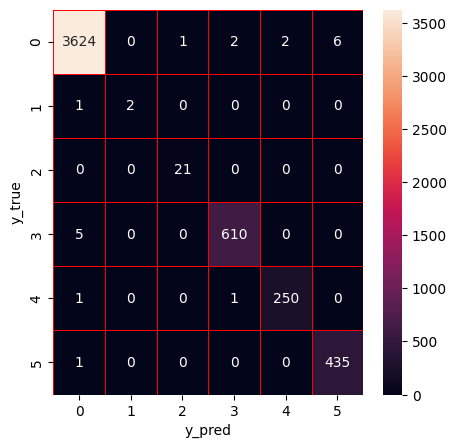

In [55]:
et_hpo = ExtraTreesClassifier(n_estimators = 53, min_samples_leaf = 1, max_depth = 31, min_samples_split = 5, max_features = 20, criterion = 'entropy')
et_hpo.fit(X_train,y_train) 
et_score=et_hpo.score(X_test,y_test)
y_predict=et_hpo.predict(X_test)
y_true=y_test
print('Accuracy of ET: '+ str(et_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of ET: '+(str(precision)))
print('Recall of ET: '+(str(recall)))
print('F1-score of ET: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [56]:
et_train=et_hpo.predict(X_train)
et_test=et_hpo.predict(X_test)

### Apply Stacking
The ensemble model that combines the four ML models (DT, RF, ET, XGBoost)

In [57]:
base_predictions_train = pd.DataFrame( {
    'DecisionTree': dt_train.ravel(),
        'RandomForest': rf_train.ravel(),
     'ExtraTrees': et_train.ravel(),
     'XgBoost': xg_train.ravel(),
    })
base_predictions_train.head(5)

,DecisionTree,RandomForest,ExtraTrees,XgBoost
0,0,0,0,0
1,0,0,0,0
2,4,4,4,4
3,0,0,0,0
4,0,0,0,0


In [58]:
dt_train=dt_train.reshape(-1, 1)
et_train=et_train.reshape(-1, 1)
rf_train=rf_train.reshape(-1, 1)
xg_train=xg_train.reshape(-1, 1)
dt_test=dt_test.reshape(-1, 1)
et_test=et_test.reshape(-1, 1)
rf_test=rf_test.reshape(-1, 1)
xg_test=xg_test.reshape(-1, 1)

In [59]:
dt_train.shape

(20760, 1)

In [60]:
x_train = np.concatenate(( dt_train, et_train, rf_train, xg_train), axis=1)
x_test = np.concatenate(( dt_test, et_test, rf_test, xg_test), axis=1)

Accuracy of Stacking: 0.9961708988311165
Precision of Stacking: 0.9961857418170428
Recall of Stacking: 0.9961708988311165
F1-score of Stacking: 0.9961537750714661
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3635
           1       1.00      0.67      0.80         3
           2       0.95      1.00      0.98        21
           3       1.00      0.99      0.99       615
           4       0.99      0.99      0.99       252
           5       0.99      1.00      0.99       436

    accuracy                           1.00      4962
   macro avg       0.99      0.94      0.96      4962
weighted avg       1.00      1.00      1.00      4962



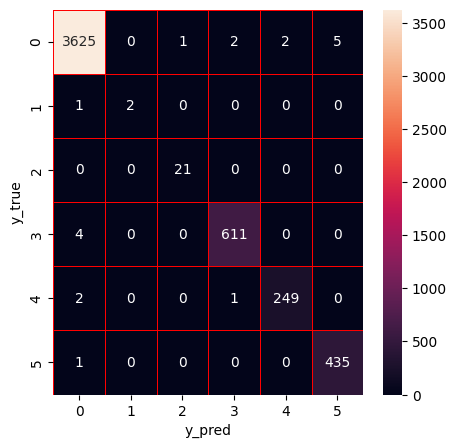

In [61]:
stk = xgb.XGBClassifier().fit(x_train, y_train)
y_predict=stk.predict(x_test)
y_true=y_test
stk_score=accuracy_score(y_true,y_predict)
print('Accuracy of Stacking: '+ str(stk_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of Stacking: '+(str(precision)))
print('Recall of Stacking: '+(str(recall)))
print('F1-score of Stacking: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

#### Hyperparameter optimization (HPO) of the stacking ensemble model (XGBoost) using Bayesian optimization with tree-based Parzen estimator (BO-TPE)
Based on the GitHub repo for HPO: https://github.com/LiYangHart/Hyperparameter-Optimization-of-Machine-Learning-Algorithms

In [62]:
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials
from sklearn.model_selection import cross_val_score, StratifiedKFold
def objective(params):
    params = {
        'n_estimators': int(params['n_estimators']), 
        'max_depth': int(params['max_depth']),
        'learning_rate':  abs(float(params['learning_rate'])),

    }
    clf = xgb.XGBClassifier( **params)
    clf.fit(x_train, y_train)
    y_pred = clf.predict(x_test)
    score = accuracy_score(y_test, y_pred)

    return {'loss':-score, 'status': STATUS_OK }

space = {
    'n_estimators': hp.quniform('n_estimators', 10, 100, 5),
    'max_depth': hp.quniform('max_depth', 4, 100, 1),
    'learning_rate': hp.normal('learning_rate', 0.01, 0.9),
}

best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=20)
print("XGBoost: Hyperopt estimated optimum {}".format(best))

100%|████████████████████████████████████████████████| 20/20 [00:01<00:00, 10.21trial/s, best loss: -0.9961708988311165]
XGBoost: Hyperopt estimated optimum {'learning_rate': 0.13542096855220903, 'max_depth': 79.0, 'n_estimators': 20.0}


Accuracy of XGBoost: 0.9961708988311165
Precision of XGBoost: 0.9961857418170428
Recall of XGBoost: 0.9961708988311165
F1-score of XGBoost: 0.9961537750714661
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3635
           1       1.00      0.67      0.80         3
           2       0.95      1.00      0.98        21
           3       1.00      0.99      0.99       615
           4       0.99      0.99      0.99       252
           5       0.99      1.00      0.99       436

    accuracy                           1.00      4962
   macro avg       0.99      0.94      0.96      4962
weighted avg       1.00      1.00      1.00      4962



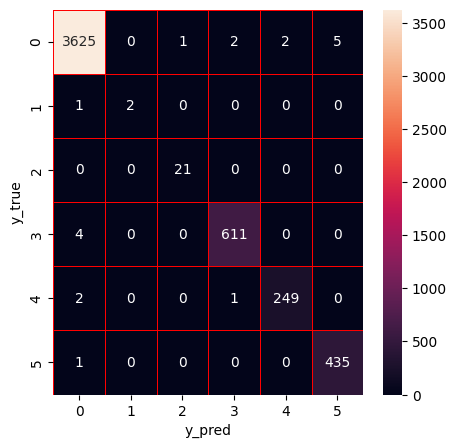

In [63]:
xg = xgb.XGBClassifier(learning_rate= 0.19229249758051492, n_estimators = 30, max_depth = 36)
xg.fit(x_train,y_train)
xg_score=xg.score(x_test,y_test)
y_predict=xg.predict(x_test)
y_true=y_test
print('Accuracy of XGBoost: '+ str(xg_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of XGBoost: '+(str(precision)))
print('Recall of XGBoost: '+(str(recall)))
print('F1-score of XGBoost: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

## Anomaly-based IDS

### Generate the port-scan datasets for unknown attack detection

In [64]:
df = pd.read_csv('./data MTH/CICIDS2017_sample_km.csv')
print("Dataset loaded successfully from data MTH. Shape:", df.shape)

Dataset loaded successfully from data MTH. Shape: (24807, 79)


In [65]:
df.Label.value_counts()

Label
0    18173
3     3073
6     2180
5     1261
2      106
1       14
Name: count, dtype: int64

In [66]:
df1 = df[df['Label'] != 5]
df1['Label'][df1['Label'] > 0] = 1
df1.to_csv('./data MTH/CICIDS2017_sample_km_without_portscan.csv',index=0)

In [67]:
df2 = df[df['Label'] == 5]
df2['Label'][df2['Label'] == 5] = 1
df2.to_csv('./data MTH/CICIDS2017_sample_km_portscan.csv',index=0)

### Read the generated datasets for unknown attack detection

In [68]:
df1 = pd.read_csv('./data MTH/CICIDS2017_sample_km_without_portscan.csv')
df2 = pd.read_csv('./data MTH/CICIDS2017_sample_km_portscan.csv')

In [69]:
features = df1.drop(['Label'],axis=1).dtypes[df1.dtypes != 'object'].index
df1[features] = df1[features].apply(
    lambda x: (x - x.mean()) / (x.std()))
df2[features] = df2[features].apply(
    lambda x: (x - x.mean()) / (x.std()))
df1 = df1.fillna(0)
df2 = df2.fillna(0)

In [70]:
df1.Label.value_counts()

Label
0    18173
3     3073
6     2180
2      106
1       14
Name: count, dtype: int64

In [71]:
df2.Label.value_counts()

Label
5    1261
Name: count, dtype: int64

In [72]:
df2p=df1[df1['Label']==0]
df2pp=df2p.sample(n=None, frac=1255/18225, replace=False, weights=None, random_state=None, axis=0)
df2=pd.concat([df2, df2pp])

In [73]:
df2.Label.value_counts()

Label
5    1261
0    1251
Name: count, dtype: int64

In [74]:
df = pd.concat([df1, df2], axis=0, ignore_index=True)

In [75]:
X = df.drop(['Label'],axis=1) .values
y = df.iloc[:, -1].values.reshape(-1,1)
y=np.ravel(y)
pd.Series(y).value_counts()

0    19424
3     3073
6     2180
5     1261
2      106
1       14
Name: count, dtype: int64

### Feature engineering (IG, FCBF, and KPCA)

#### Feature selection by information gain (IG)

In [76]:
from sklearn.feature_selection import mutual_info_classif
importances = mutual_info_classif(X, y)

In [77]:
# calculate the sum of importance scores
f_list = sorted(zip(map(lambda x: round(x, 4), importances), features), reverse=True)
Sum = 0
fs = []
for i in range(0, len(f_list)):
    Sum = Sum + f_list[i][0]
    fs.append(f_list[i][1])

In [78]:
# select the important features from top to bottom until the accumulated importance reaches 90%
f_list2 = sorted(zip(map(lambda x: round(x, 4), importances/Sum), features), reverse=True)
Sum2 = 0
fs = []
for i in range(0, len(f_list2)):
    Sum2 = Sum2 + f_list2[i][0]
    fs.append(f_list2[i][1])
    if Sum2>=0.9:
        break        

In [79]:
X_fs = df[fs].values

In [80]:
X_fs.shape

(26058, 55)

In [81]:
X_fs

array([[-0.37818216, -0.56074047, -0.23542308, ..., -0.34410756,
        -0.33110407, -0.68278732],
       [-0.37818216, -0.56074047, -0.23846857, ..., -0.34410756,
        -0.33110407, -0.68278732],
       [-0.37818216, -0.56074047, -0.23846857, ..., -0.34410756,
        -0.33110407, -0.68278732],
       ...,
       [-0.37809043, -0.54535157, -0.54758641, ..., -0.09993066,
        -0.08405815, -0.68278732],
       [-0.37818216, -0.56074047, -0.29937849, ..., -0.34410756,
        -0.33110407, -0.68278732],
       [-0.36845928,  3.82416153,  0.46296451, ..., -0.34410756,
        -0.33110407,  1.46452271]])

#### Feature selection by Fast Correlation Based Filter (FCBF)

The module is imported from the GitHub repo: https://github.com/SantiagoEG/FCBF_module

In [82]:
from FCBF_module import FCBF, FCBFK, FCBFiP, get_i
fcbf = FCBFK(k = 20)
#fcbf.fit(X_fs, y)

In [83]:
X_fss = fcbf.fit_transform(X_fs,y)

In [84]:
X_fss.shape

(26058, 20)

In [85]:
X_fss

array([[-0.37818216, -0.68278732, -0.56074047, ..., -0.15951497,
        -0.12731106, -0.01077929],
       [-0.37818216, -0.68278732, -0.56074047, ..., -0.15951497,
        -0.12731106, -0.01077929],
       [-0.37818216, -0.68278732, -0.56074047, ..., -0.15951497,
        -0.12731106, -0.01077929],
       ...,
       [-0.37809043, -0.68278732, -0.54535157, ..., -0.12763553,
        -0.07999903, -0.01077929],
       [-0.37818216, -0.68278732, -0.56074047, ..., -0.15951497,
        -0.12731106, -0.00946233],
       [-0.36845928,  1.46452271,  3.82416153, ..., -0.15951497,
        -0.12731106, -0.00946233]])

####  kernel principal component analysis (KPCA)

In [86]:
#from sklearn.decomposition import KernelPCA
#kpca = KernelPCA(n_components = 10, kernel = 'rbf')
#kpca.fit(X_fss, y)
#X_kpca = kpca.transform(X_fss)

from sklearn.decomposition import PCA
kpca = PCA(n_components = 10)
kpca.fit(X_fss, y)
X_kpca = kpca.transform(X_fss)

### Train-test split after feature selection

In [87]:
X_train = X_kpca[:len(df1)]
y_train = y[:len(df1)]
X_test = X_kpca[len(df1):]
y_test = y[len(df1):]

### Solve class-imbalance by SMOTE

In [88]:
pd.Series(y_train).value_counts()

0    18173
3     3073
6     2180
2      106
1       14
Name: count, dtype: int64

In [89]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy={1: 18225})
X_train, y_train = smote.fit_resample(X_train, y_train)

In [90]:
pd.Series(y_train).value_counts()

1    18225
0    18173
3     3073
6     2180
2      106
Name: count, dtype: int64

In [91]:
pd.Series(y_test).value_counts()

5    1261
0    1251
Name: count, dtype: int64

### Apply the cluster labeling (CL) k-means method

In [92]:
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN,MeanShift
from sklearn.cluster import SpectralClustering,AgglomerativeClustering,AffinityPropagation,Birch,MiniBatchKMeans,MeanShift 
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from sklearn.metrics import classification_report
from sklearn import metrics

In [93]:
def CL_kmeans(X_train, X_test, y_train, y_test,n,b=100):
    km_cluster = MiniBatchKMeans(n_clusters=n,batch_size=b)
    result = km_cluster.fit_predict(X_train)
    result2 = km_cluster.predict(X_test)

    count=0
    a=np.zeros(n)
    b=np.zeros(n)
    for v in range(0,n):
        for i in range(0,len(y_train)):
            if result[i]==v:
                if y_train[i]==1:
                    a[v]=a[v]+1
                else:
                    b[v]=b[v]+1
    list1=[]
    list2=[]
    for v in range(0,n):
        if a[v]<=b[v]:
            list1.append(v)
        else: 
            list2.append(v)
    for v in range(0,len(y_test)):
        if result2[v] in list1:
            result2[v]=0
        elif result2[v] in list2:
            result2[v]=1
        else:
            print("-1")
    print(classification_report(y_test, result2))
    cm=confusion_matrix(y_test,result2)
    acc=metrics.accuracy_score(y_test,result2)
    print(str(acc))
    print(cm)

In [94]:
CL_kmeans(X_train, X_test, y_train, y_test, 8)

              precision    recall  f1-score   support

           0       0.52      0.90      0.66      1251
           1       0.00      0.00      0.00         0
           5       0.00      0.00      0.00      1261

    accuracy                           0.45      2512
   macro avg       0.17      0.30      0.22      2512
weighted avg       0.26      0.45      0.33      2512

0.44745222929936307
[[1124  127    0]
 [   0    0    0]
 [1049  212    0]]


### Hyperparameter optimization of CL-k-means
Tune "k"

In [96]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.8 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 23.3.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [97]:
#Hyperparameter optimization by BO-GP
from skopt.space import Real, Integer
from skopt.utils import use_named_args
from sklearn import metrics

space  = [Integer(2, 50, name='n_clusters')]
@use_named_args(space)
def objective(**params):
    km_cluster = MiniBatchKMeans(batch_size=100, **params)
    n=params['n_clusters']
    
    result = km_cluster.fit_predict(X_train)
    result2 = km_cluster.predict(X_test)

    count=0
    a=np.zeros(n)
    b=np.zeros(n)
    for v in range(0,n):
        for i in range(0,len(y_train)):
            if result[i]==v:
                if y_train[i]==1:
                    a[v]=a[v]+1
                else:
                    b[v]=b[v]+1
    list1=[]
    list2=[]
    for v in range(0,n):
        if a[v]<=b[v]:
            list1.append(v)
        else: 
            list2.append(v)
    for v in range(0,len(y_test)):
        if result2[v] in list1:
            result2[v]=0
        elif result2[v] in list2:
            result2[v]=1
        else:
            print("-1")
    cm=metrics.accuracy_score(y_test,result2)
    print(str(n)+" "+str(cm))
    return (1-cm)
from skopt import gp_minimize
import time
t1=time.time()
res_gp = gp_minimize(objective, space, n_calls=20, random_state=0)
t2=time.time()
print(t2-t1)
print("Best score=%.4f" % (1-res_gp.fun))
print("""Best parameters: n_clusters=%d""" % (res_gp.x[0]))

30 0.464171974522293
43 0.48009554140127386
43 0.46695859872611467
43 0.44904458598726116
32 0.46894904458598724
20 0.4323248407643312
16 0.46656050955414013
5 0.4450636942675159
15 0.40406050955414013
25 0.4140127388535032
50 0.4494426751592357
38 0.4502388535031847
42 0.4637738853503185
41 0.4785031847133758
39 0.4554140127388535
46 0.42078025477707004
33 0.4020700636942675
25 0.44904458598726116
26 0.48009554140127386
14 0.3590764331210191
34.261210680007935
Best score=0.4801
Best parameters: n_clusters=43


In [98]:
#Hyperparameter optimization by BO-TPE
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.cluster import MiniBatchKMeans
from sklearn import metrics

def objective(params):
    params = {
        'n_clusters': int(params['n_clusters']), 
    }
    km_cluster = MiniBatchKMeans(batch_size=100, **params)
    n=params['n_clusters']
    
    result = km_cluster.fit_predict(X_train)
    result2 = km_cluster.predict(X_test)

    count=0
    a=np.zeros(n)
    b=np.zeros(n)
    for v in range(0,n):
        for i in range(0,len(y_train)):
            if result[i]==v:
                if y_train[i]==1:
                    a[v]=a[v]+1
                else:
                    b[v]=b[v]+1
    list1=[]
    list2=[]
    for v in range(0,n):
        if a[v]<=b[v]:
            list1.append(v)
        else: 
            list2.append(v)
    for v in range(0,len(y_test)):
        if result2[v] in list1:
            result2[v]=0
        elif result2[v] in list2:
            result2[v]=1
        else:
            print("-1")
    score=metrics.accuracy_score(y_test,result2)
    print(str(params['n_clusters'])+" "+str(score))
    return {'loss':1-score, 'status': STATUS_OK }
space = {
    'n_clusters': hp.quniform('n_clusters', 2, 50, 1),
}

best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=20)
print("Random Forest: Hyperopt estimated optimum {}".format(best))

13 0.40485668789808915                                                                                                  
45 0.4753184713375796                                                                                                   
12 0.4769108280254777                                                                                                   
47 0.42754777070063693                                                                                                  
28 0.4629777070063694                                                                                                   
22 0.4036624203821656                                                                                                   
27 0.4589968152866242                                                                                                   
36 0.46695859872611467                                                                                                  
38 0.445859872611465            

In [99]:
CL_kmeans(X_train, X_test, y_train, y_test, 43)

              precision    recall  f1-score   support

           0       0.61      0.87      0.71      1251
           1       0.00      0.00      0.00         0
           5       0.00      0.00      0.00      1261

    accuracy                           0.43      2512
   macro avg       0.20      0.29      0.24      2512
weighted avg       0.30      0.43      0.36      2512

0.43312101910828027
[[1088  163    0]
 [   0    0    0]
 [ 709  552    0]]


95% of the code has been shared, and the remaining 5% is retained for future extension.  
Thank you for your interest and more details are in the paper.

In [100]:
import joblib
import os
from sklearn.cluster import MiniBatchKMeans

os.makedirs('./data MTH/models_emulation', exist_ok=True)

joblib.dump(kpca, './data MTH/models_emulation/mth_pca_extractor.joblib')

joblib.dump(xg, './data MTH/models_emulation/mth_xgboost_optimized.joblib')
joblib.dump(rf_hpo, './data MTH/models_emulation/mth_random_forest_optimized.joblib')

print("K-Means final...")
final_kmeans = MiniBatchKMeans(n_clusters=43, batch_size=100, random_state=0)
final_kmeans.fit(X_train) 
joblib.dump(final_kmeans, './data MTH/models_emulation/mth_kmeans_anomalies.joblib')


K-Means final...


['./data MTH/models_emulation/mth_kmeans_anomalies.joblib']